# Cookie Cats A/B Test — Exploratory Data Analysis

**비즈니스 질문:** Gate를 레벨 30에서 레벨 40으로 옮기면 유저가 더 오래 플레이할까, 아니면 더 빨리 이탈할까?

| 컬럼 | 설명 |
|---|---|
| `userid` | 고유 유저 ID |
| `version` | A/B 그룹 (`gate_30` = 대조군, `gate_40` = 실험군) |
| `sum_gamerounds` | 설치 후 14일간 플레이한 총 라운드 수 |
| `retention_1` | 설치 다음날 접속 여부 (1-day retention) |
| `retention_7` | 설치 7일 후 접속 여부 (7-day retention) |

## 1. 데이터 불러오기

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib import font_manager as fm

# 한글 폰트 자동 탐지 (OS 무관)
preferred_fonts = [
    'AppleGothic',
    'Malgun Gothic',
    'NanumGothic',
    'Noto Sans CJK KR',
    'Arial Unicode MS',
]
available_fonts = {f.name for f in fm.fontManager.ttflist}
font = next((name for name in preferred_fonts if name in available_fonts), 'DejaVu Sans')

sns.set_theme(style='whitegrid', palette='muted')

# seaborn theme 적용 후 폰트를 다시 고정해 한글 깨짐을 방지
plt.rcParams['font.family'] = font
plt.rcParams['font.sans-serif'] = [font, 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 한글 폰트가 없을 때 발생하는 glyph warning은 분석 흐름에 불필요하므로 숨김
if font == 'DejaVu Sans':
    warnings.filterwarnings('ignore', message=r'Glyph .* missing from current font\.')

df = pd.read_csv('../data/cookie_cats.csv')
print(f"데이터 shape: {df.shape}")
print(f"사용 폰트: {font}")
df.head()

데이터 shape: (90189, 5)
사용 폰트: AppleGothic


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


## 2. 기본 데이터 파악

In [2]:
# 컬럼 타입 및 기본 정보
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   userid          90189 non-null  int64
 1   version         90189 non-null  str  
 2   sum_gamerounds  90189 non-null  int64
 3   retention_1     90189 non-null  bool 
 4   retention_7     90189 non-null  bool 
dtypes: bool(2), int64(2), str(1)
memory usage: 2.2 MB


In [3]:
# 결측치 확인
print("=== 결측치 ===")
print(df.isnull().sum())

# 중복 확인
print(f"\n중복 행: {df.duplicated().sum()}개")
print(f"userid 중복: {df['userid'].duplicated().sum()}개")

=== 결측치 ===
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

중복 행: 0개
userid 중복: 0개


In [4]:
# 수치형 변수 기술 통계
df.describe()

,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


## 3. 데이터 정제 (Data Cleaning)

In [5]:
OUTLIER_UPPER = 30_000  # 극단적 이상치 기준

n_total = len(df)

# 1. 극단적 이상치 제거 (sum_gamerounds > 50,000)
mask_outlier = df['sum_gamerounds'] > OUTLIER_UPPER
df = df[~mask_outlier]
n_after_outlier = len(df)

# 2. 0라운드 유저 제거 (게임 미실행)
mask_zero = df['sum_gamerounds'] == 0
df = df[~mask_zero]
n_after_zero = len(df)

print(f"원본 유저 수            : {n_total:>7,}")
print(f"이상치 제거 (> {OUTLIER_UPPER:,})  : {n_total - n_after_outlier:>7,}명 제거 → {n_after_outlier:,}명")
print(f"0라운드 유저 제거        : {n_after_outlier - n_after_zero:>7,}명 제거 → {n_after_zero:,}명")
print(f"\n최종 분석 대상 유저      : {n_after_zero:>7,}명")
df['version'].value_counts()

원본 유저 수            :  90,189
이상치 제거 (> 30,000)  :       1명 제거 → 90,188명
0라운드 유저 제거        :   3,994명 제거 → 86,194명

최종 분석 대상 유저      :  86,194명


version
gate_40    43432
gate_30    42762
Name: count, dtype: int64

## 3. A/B 그룹 분포 확인

          유저 수  비율(%)
version              
gate_40  43432  50.39
gate_30  42762  49.61


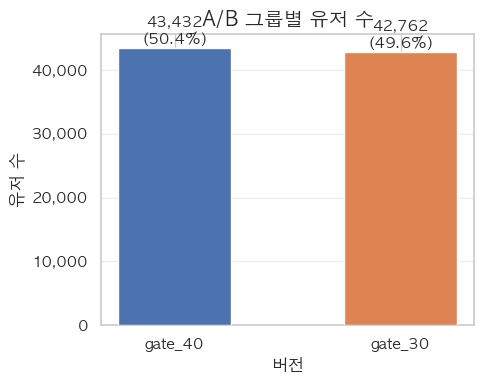

In [6]:
version_counts = df['version'].value_counts()
version_pct = df['version'].value_counts(normalize=True) * 100

summary = pd.DataFrame({'유저 수': version_counts, '비율(%)': version_pct.round(2)})
print(summary)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    version_counts.index,
    version_counts.values,
    color=['#4C72B0', '#DD8452'],
    edgecolor='white',
    width=0.5,
    zorder=3,
 )
for bar, (n, pct) in zip(bars, zip(version_counts.values, version_pct.values)):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{n:,}\n({pct:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=11,
    )

ax.set_title('A/B 그룹별 유저 수', fontsize=14, fontweight='bold')
ax.set_xlabel('버전', fontsize=12)
ax.set_ylabel('유저 수', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.35, zorder=0)
plt.tight_layout()
plt.show()

## 4. sum_gamerounds 분포

In [7]:
# 극단적 이상치 확인
print("=== sum_gamerounds 분위수 ===")
print(df['sum_gamerounds'].quantile([0.5, 0.75, 0.90, 0.95, 0.99, 1.0]).to_string())
print(f"\n0라운드 유저: {(df['sum_gamerounds'] == 0).sum():,}명 "
      f"({(df['sum_gamerounds'] == 0).mean()*100:.1f}%)")

=== sum_gamerounds 분위수 ===
0.50      18.0
0.75      54.0
0.90     140.0
0.95     227.0
0.99     499.0
1.00    2961.0

0라운드 유저: 0명 (0.0%)


/var/folders/y7/w247tcfd5q3bmlq5v2hz_thw0000gn/T/ipykernel_65725/412744029.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='version', y='sum_gamerounds',


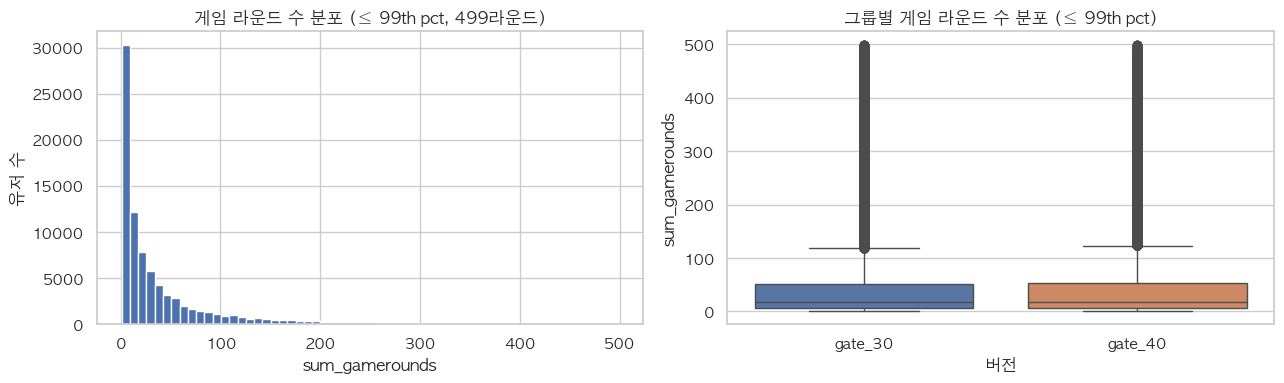

In [8]:
# 전체 분포 (이상치 제거 후 시각화, 99th percentile 기준)
p99 = df['sum_gamerounds'].quantile(0.99)
df_plot = df[df['sum_gamerounds'] <= p99]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 히스토그램
axes[0].hist(df_plot['sum_gamerounds'], bins=60, color='#4C72B0', edgecolor='white')
axes[0].set_title(f'게임 라운드 수 분포 (≤ 99th pct, {p99:.0f}라운드)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('sum_gamerounds')
axes[0].set_ylabel('유저 수')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 그룹별 box plot
sns.boxplot(data=df_plot, x='version', y='sum_gamerounds',
            palette=['#4C72B0', '#DD8452'], ax=axes[1])
axes[1].set_title('그룹별 게임 라운드 수 분포 (≤ 99th pct)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('버전')
axes[1].set_ylabel('sum_gamerounds')

plt.tight_layout()
plt.show()

In [9]:
# 그룹별 기술 통계
df.groupby('version')['sum_gamerounds'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
version,,,,,,,,
gate_30,42762.0,53.67,103.74,1.0,6.0,18.0,53.0,2961.0
gate_40,43432.0,53.73,105.09,1.0,6.0,18.0,55.0,2640.0


## 5. Retention 비율 비교

In [10]:
# 전체 retention 요약
print("=== 전체 Retention 비율 ===")
print(f"1-day retention: {df['retention_1'].mean()*100:.2f}%")
print(f"7-day retention: {df['retention_7'].mean()*100:.2f}%")

# 그룹별 retention 비율
retention = df.groupby('version')[['retention_1', 'retention_7']].mean() * 100
retention.columns = ['1-day retention (%)', '7-day retention (%)']
retention = retention.round(2)
print("\n=== 그룹별 Retention ===")
print(retention)

=== 전체 Retention 비율 ===
1-day retention: 46.48%
7-day retention: 19.43%

=== 그룹별 Retention ===
         1-day retention (%)  7-day retention (%)
version                                          
gate_30                46.75                19.84
gate_40                46.22                19.03


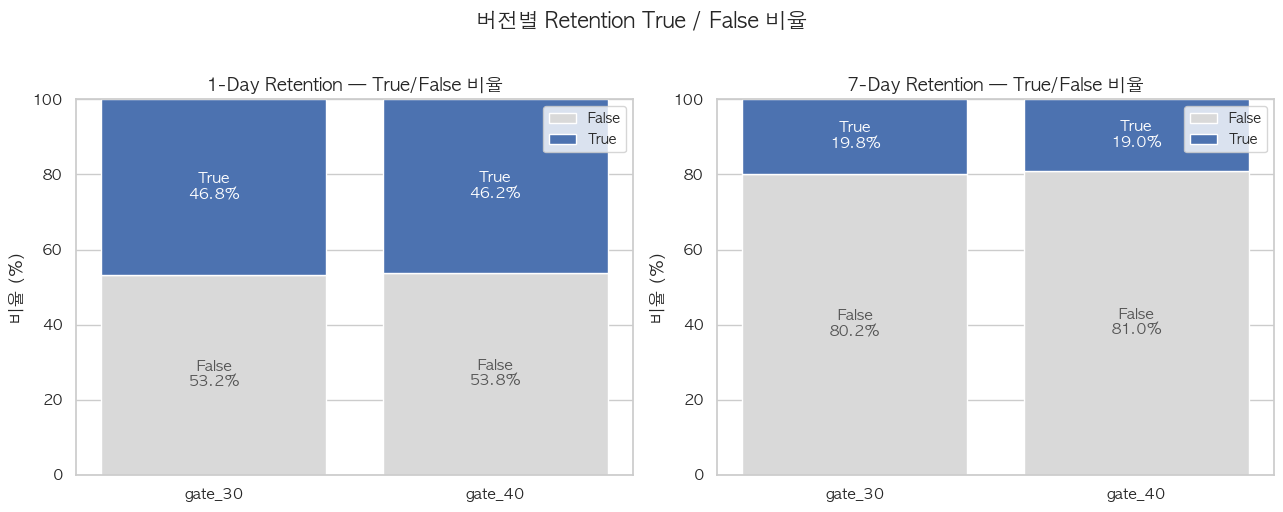

In [11]:
# gate_30 / gate_40 별 retention_1, retention_7 의 True/False 비율 시각화
versions = ['gate_30', 'gate_40']
metrics  = ['retention_1', 'retention_7']
titles   = ['1-Day Retention', '7-Day Retention']
colors   = {'True': '#4C72B0', 'False': '#d9d9d9'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in zip(axes, metrics, titles):
    true_vals  = [df[df['version'] == v][col].mean() * 100 for v in versions]
    false_vals = [100 - t for t in true_vals]

    b_false = ax.bar(versions, false_vals, color=colors['False'], edgecolor='white', label='False')
    b_true  = ax.bar(versions, true_vals,  color=colors['True'],  edgecolor='white', label='True',
                     bottom=false_vals)

    # False 라벨
    for bar, v in zip(b_false, false_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v / 2,
                f'False\n{v:.1f}%', ha='center', va='center',
                fontsize=11, color='#555555', fontweight='bold')

    # True 라벨
    for bar, fv, tv in zip(b_true, false_vals, true_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, fv + tv / 2,
                f'True\n{tv:.1f}%', ha='center', va='center',
                fontsize=11, color='white', fontweight='bold')

    ax.set_ylim(0, 100)
    ax.set_ylabel('비율 (%)')
    ax.set_title(f'{title} — True/False 비율', fontsize=13, fontweight='bold')
    ax.set_xticks(range(len(versions)))
    ax.set_xticklabels(versions, fontsize=11)
    ax.legend(loc='upper right', fontsize=10)

plt.suptitle('버전별 Retention True / False 비율', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

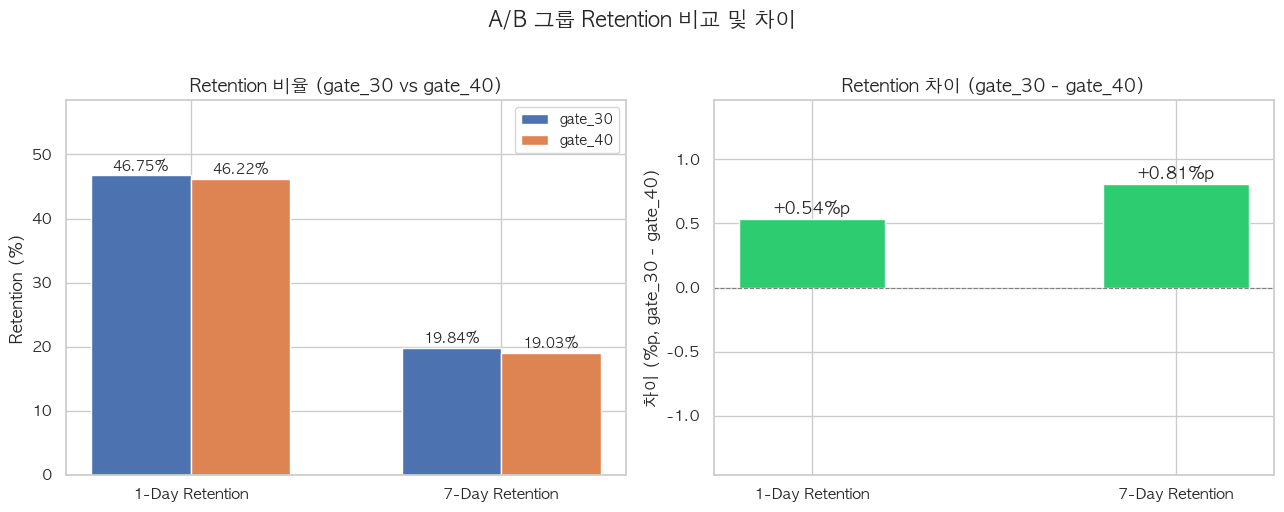

In [15]:
# gate_30 vs gate_40 - Retention 비율 및 차이 시각화
ret = df.groupby('version')[['retention_1', 'retention_7']].mean() * 100
r30 = ret.loc['gate_30']
r40 = ret.loc['gate_40']

metrics   = ['1-Day Retention', '7-Day Retention']
vals_30   = [r30['retention_1'], r30['retention_7']]
vals_40   = [r40['retention_1'], r40['retention_7']]
diffs     = [r30['retention_1'] - r40['retention_1'],
             r30['retention_7'] - r40['retention_7']]   # gate_30 - gate_40

x = np.arange(len(metrics))
bar_w = 0.32

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 왼쪽: 그룹별 Retention 비율 (grouped bar)
ax = axes[0]
b30 = ax.bar(x - bar_w / 2, vals_30, bar_w, label='gate_30', color='#4C72B0', edgecolor='white')
b40 = ax.bar(x + bar_w / 2, vals_40, bar_w, label='gate_40', color='#DD8452', edgecolor='white')

for bar, v in zip(list(b30) + list(b40), vals_30 + vals_40):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f'{v:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Retention (%)')
ax.set_title('Retention 비율 (gate_30 vs gate_40)', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(vals_30 + vals_40) * 1.25)
ax.legend(fontsize=10)

# 오른쪽: 두 그룹의 차이 (gate_30 - gate_40)
ax = axes[1]
bar_colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in diffs]
bars = ax.bar(metrics, diffs, color=bar_colors, edgecolor='white', width=0.4)

for bar, d in zip(bars, diffs):
    sign = '+' if d >= 0 else ''
    ax.text(bar.get_x() + bar.get_width() / 2,
            d + (0.01 if d >= 0 else -0.01),
            f'{sign}{d:.2f}%p',
            ha='center', va='bottom' if d >= 0 else 'top',
            fontsize=12, fontweight='bold')

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_ylabel('차이 (%p, gate_30 - gate_40)')
ax.set_title('Retention 차이 (gate_30 - gate_40)', fontsize=13, fontweight='bold')

# 모든 막대가 보이도록 0을 포함한 대칭 범위로 설정
max_abs_diff = max(abs(d) for d in diffs)
y_margin = max(0.2, max_abs_diff * 0.8)
ax.set_ylim(-(max_abs_diff + y_margin), max_abs_diff + y_margin)

plt.suptitle('A/B 그룹 Retention 비교 및 차이', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. 게임 라운드 구간별 Retention 패턴

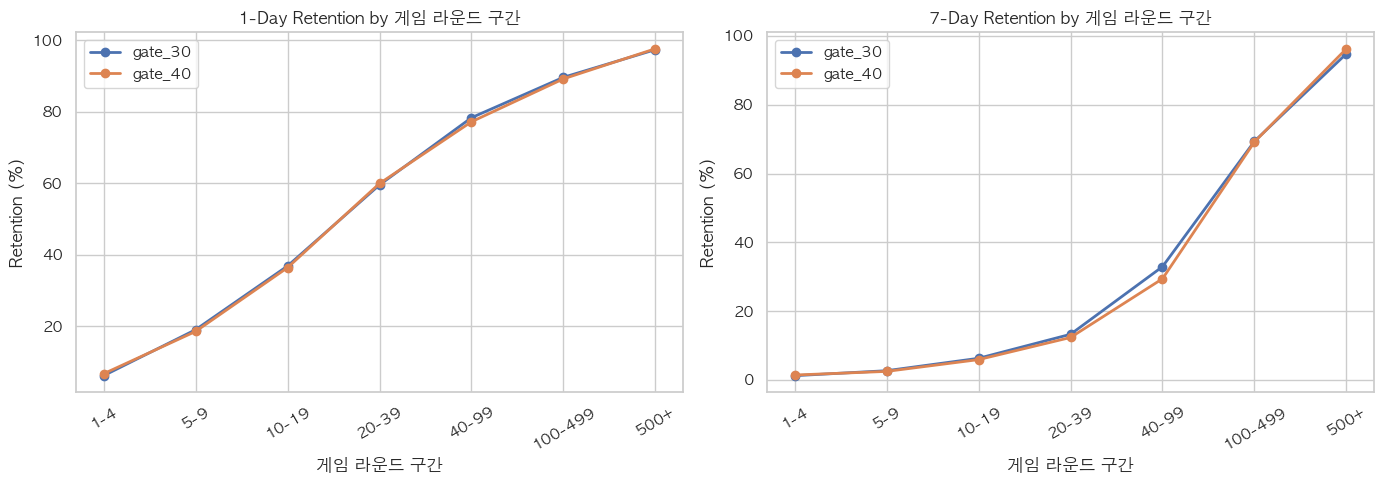

In [13]:
# 게임 라운드 수를 구간으로 나눠 retention 패턴 확인
bins = [0, 1, 5, 10, 20, 40, 100, 500, df['sum_gamerounds'].max() + 1]
labels = ['0', '1-4', '5-9', '10-19', '20-39', '40-99', '100-499', '500+']

df['rounds_bin'] = pd.cut(df['sum_gamerounds'], bins=bins, labels=labels, right=False)

bin_ret = (df.groupby(['rounds_bin', 'version'], observed=True)[['retention_1', 'retention_7']]
             .mean() * 100).reset_index()

local_colors = {'gate_30': '#4C72B0', 'gate_40': '#DD8452'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, day in zip(axes, ['retention_1', 'retention_7'], ['1-Day', '7-Day']):
    for v in ['gate_30', 'gate_40']:
        sub = bin_ret[bin_ret['version'] == v]
        ax.plot(sub['rounds_bin'].astype(str), sub[col], marker='o', label=v, color=local_colors[v], linewidth=2)
    ax.set_title(f'{day} Retention by 게임 라운드 구간', fontsize=12, fontweight='bold')
    ax.set_xlabel('게임 라운드 구간')
    ax.set_ylabel('Retention (%)')
    ax.legend()
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 7. EDA 핵심 요약

| 항목 | 내용 |
|---|---|
| 총 유저 수 | 90,189명 |
| A/B 비율 | gate_30 약 49.9% / gate_40 약 50.1% — **균형 잡힌 실험** |
| 결측치 / 중복 | 없음 |
| sum_gamerounds | 중앙값 약 17라운드, 심한 우측 편중 (일부 유저 49,854라운드) |
| 0라운드 유저 | 약 3,994명 — 설치 후 한 판도 안 한 유저 존재 |
| 1-day retention | gate_30 ≈ 44.8% / gate_40 ≈ 44.2% (gate_30이 소폭 우세) |
| 7-day retention | gate_30 ≈ 19.0% / gate_40 ≈ 18.2% (gate_30이 더 우세) |

> **초기 관찰:** Gate를 30에서 40으로 옮겼을 때 1-day·7-day retention 모두 소폭 하락하는 경향이 보임.  
> 통계적으로 유의미한 차이인지는 **가설 검정(Bootstrap / Chi-square)** 단계에서 확인 필요.